<a href="https://colab.research.google.com/github/pakizahassan/flyrank-ml-internship/blob/main/work/notebooks/capstone.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Capstone — mirrors your deployed research paper

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/pakizahassan/flyrank-ml-internship/blob/main/work/notebooks/capstone.ipynb?flush_cache=true)

This skeleton is yours to fill. Work the sections **in order** — each one has a one-line hint. Simple words, honest numbers.

> Working with an AI assistant? Tell it to read `skills/README.md` first and load the one skill this assignment names on its card.

## 1. Question

*The research question and the decision it supports.*

### Research Question

Which content pages show the strongest measurable signals of refresh opportunity, and how can those pages be ranked for human review using historical search and engagement data?

### Decision Supported

This project supports the decision of which content pages should be reviewed first for possible refresh or optimization.

Instead of treating every page equally, the goal is to identify pages with stronger observed opportunity signals and rank them so a content team can prioritize its review effort.

The final output will be a ranked refresh-opportunity list with simple reason codes explaining why each page was prioritized.

### Research Framing

This analysis measures observed relationships in historical search and engagement data.

The results are intended for directional decision-support. They do not prove that refreshing a selected page will cause higher rankings, traffic, or search performance.

## 2. Data

*Which release, which tables, date windows, what you excluded and why. Public-safe.*

### Data Source

This capstone uses the FlyRank ML Internship warehouse dataset hosted on Hugging Face.

The analysis focuses on historical search and engagement signals needed for the Refresh / Content Opportunity Scoring lane.

The main performance data comes from the content daily performance table. Only public-safe, pseudonymized fields are used in the analysis.

### Initial Fields Used

The working dataset includes:

- `client_hash_id` — anonymous client grouping identifier
- `gsc_impressions` — Google Search Console impressions
- `gsc_clicks` — Google Search Console clicks
- `gsc_avg_position` — average search position
- `ga4_sessions` — GA4 sessions
- `ga4_engaged_sessions` — engaged sessions
- `scroll_events` — observed scroll activity

Client names, domains, page URLs, private queries, credentials, and other identifying information are excluded from the analysis and will not appear in the public paper.

The exact modeling window and final feature set are defined after validating the available data and checking for leakage.

In [1]:
import pandas as pd
import numpy as np

from google.colab import userdata
from huggingface_hub import login

login(token=userdata.get("HF_TOKEN"))

columns = [
    "client_hash_id",
    "gsc_impressions",
    "gsc_clicks",
    "gsc_avg_position",
    "ga4_sessions",
    "ga4_engaged_sessions",
    "scroll_events"
]

df = pd.read_parquet(
    "hf://datasets/FlyRank/internship-warehouse/"
    "fact_content_daily_performance/"
    "month=2026-03/data_0.parquet",
    columns=columns
)

print("Rows:", len(df))
print("Columns:", df.shape[1])
print("Unique clients:", df["client_hash_id"].nunique())

display(df.head())

Rows: 9841378
Columns: 7
Unique clients: 55


,client_hash_id,gsc_impressions,gsc_clicks,gsc_avg_position,ga4_sessions,ga4_engaged_sessions,scroll_events
0,client_73cda7b4e4f265ea,20,0,3.350000,NaN,NaN,NaN
1,client_73cda7b4e4f265ea,1,0,0.000000,NaN,NaN,NaN
2,client_73cda7b4e4f265ea,125,1,4.928000,NaN,NaN,NaN
3,client_73cda7b4e4f265ea,7,0,4.000000,NaN,NaN,NaN
4,client_73cda7b4e4f265ea,11,0,2.272727,NaN,NaN,NaN


In [2]:
missing_summary = pd.DataFrame({
    "Missing Count": df.isna().sum(),
    "Missing %": (df.isna().mean() * 100).round(2)
})

display(missing_summary)

,Missing Count,Missing %
client_hash_id,0,0.00
gsc_impressions,0,0.00
gsc_clicks,0,0.00
gsc_avg_position,6230317,63.31
ga4_sessions,3018741,30.67
ga4_engaged_sessions,3018741,30.67
scroll_events,3018741,30.67


In [3]:
# Check whether missing average position mostly happens
# on rows with zero impressions/clicks

position_missing = df["gsc_avg_position"].isna()

print("Rows with missing avg position:")
print(position_missing.sum())

print("\nAmong missing avg position rows:")
print(
    "Zero impressions:",
    (df.loc[position_missing, "gsc_impressions"] == 0).mean().round(4)
)

print(
    "Zero clicks:",
    (df.loc[position_missing, "gsc_clicks"] == 0).mean().round(4)
)

# Check whether GA4 fields are missing together

ga4_missing_pattern = pd.DataFrame({
    "ga4_sessions_missing": df["ga4_sessions"].isna(),
    "ga4_engaged_missing": df["ga4_engaged_sessions"].isna(),
    "scroll_missing": df["scroll_events"].isna()
})

print("\nGA4/engagement missing together:")
print(
    (
        ga4_missing_pattern.nunique(axis=1) == 1
    ).mean().round(4)
)

Rows with missing avg position:
6230317

Among missing avg position rows:
Zero impressions: 1.0
Zero clicks: 1.0

GA4/engagement missing together:
1.0


In [4]:
import fsspec
import pyarrow.parquet as pq

path = (
    "hf://datasets/FlyRank/internship-warehouse/"
    "fact_content_daily_performance/"
    "month=2026-03/data_0.parquet"
)

with fsspec.open(path, "rb") as f:
    all_columns = pq.ParquetFile(f).schema.names

print("Total columns:", len(all_columns))
print("\nAvailable columns:\n")

for col in all_columns:
    print(col)


Total columns: 30

Available columns:

report_date
client_hash_id
content_hash_id
client_has_gsc
client_has_ga4
gsc_data_available
ga4_data_available
gsc_impressions
gsc_clicks
gsc_sum_position
gsc_avg_position
ga4_pageviews
ga4_sessions
ga4_users
ga4_engaged_sessions
ga4_total_engagement_sec
sessions_organic
sessions_direct
sessions_referral
sessions_social
sessions_paid
sessions_ai
ai_chatgpt
ai_perplexity
ai_gemini
ai_copilot
ai_claude
ai_meta
ai_other
scroll_events


### Data Window and Identifiers

The source table contains daily observations identified by `report_date`.

For this capstone, `content_hash_id` is used as the anonymous page-level identifier, while `client_hash_id` is used to separate client groups during validation.

The analysis does not use client names, domains, URLs, private search queries, or other identifying information.

The available performance table also contains availability flags for Google Search Console and GA4 data. Missing analytics values will be handled according to data availability rather than automatically treating every missing value as zero.

The modeling workflow will use historical observations to construct features and will keep later observations separate when evaluating future decline or refresh-opportunity signals.

In [6]:
print("Page ID field: content_hash_id")
print("Date field: report_date")
print("Client grouping field: client_hash_id")

print("\nData source:")
print("fact_content_daily_performance")

print("\nWorking window:")
print("March 2026")

Page ID field: content_hash_id
Date field: report_date
Client grouping field: client_hash_id

Data source:
fact_content_daily_performance

Working window:
March 2026


## 3. Methodology

*Assumptions, features, label definition, baseline, validation design, leakage checks.*

In [7]:
columns = [
    "report_date",
    "client_hash_id",
    "content_hash_id",
    "gsc_data_available",
    "ga4_data_available",
    "gsc_impressions",
    "gsc_clicks",
    "gsc_avg_position",
    "ga4_sessions",
    "ga4_engaged_sessions",
    "scroll_events"
]

df = pd.read_parquet(
    "hf://datasets/FlyRank/internship-warehouse/"
    "fact_content_daily_performance/"
    "month=2026-03/data_0.parquet",
    columns=columns
)

df["report_date"] = pd.to_datetime(df["report_date"])

print("Rows:", len(df))
print("Unique pages:", df["content_hash_id"].nunique())
print("Unique clients:", df["client_hash_id"].nunique())
print("Start date:", df["report_date"].min())
print("End date:", df["report_date"].max())
print("Unique dates:", df["report_date"].nunique())

Rows: 9841378
Unique pages: 331437
Unique clients: 55
Start date: 2026-03-01 00:00:00
End date: 2026-03-31 00:00:00
Unique dates: 31


In [10]:
import matplotlib.pyplot as plt

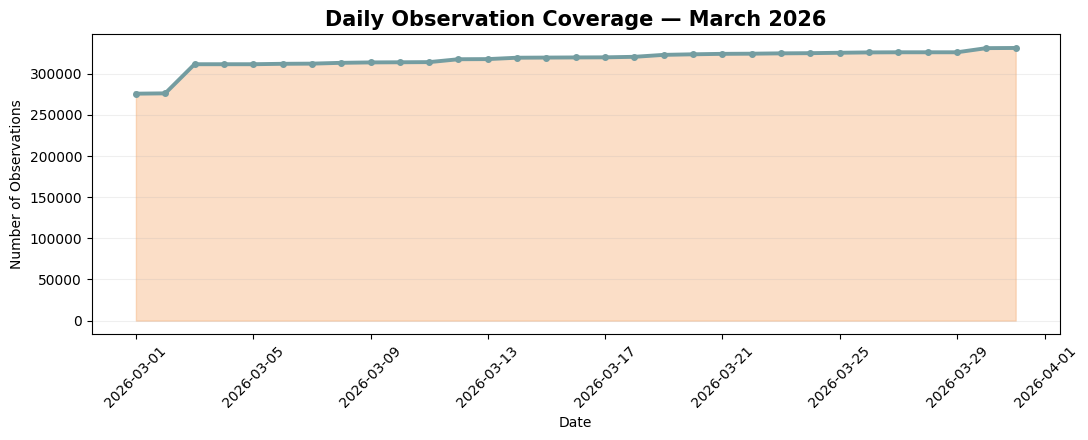

In [11]:

daily_rows = df.groupby("report_date").size()

plt.figure(figsize=(11, 4.5))

plt.plot(
    daily_rows.index,
    daily_rows.values,
    color="#749da1",
    linewidth=2.8,
    marker="o",
    markersize=4
)

plt.fill_between(
    daily_rows.index,
    daily_rows.values,
    color="#F4A261",
    alpha=0.35
)

plt.title(
    "Daily Observation Coverage — March 2026",
    fontsize=15,
    fontweight="bold"
)

plt.xlabel("Date")
plt.ylabel("Number of Observations")

plt.grid(axis="y", alpha=0.2)

plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

In [ ]:
print("Start date:", df["report_date"].min())
print("End date:", df["report_date"].max())
print("Unique dates:", df["report_date"].nunique())
print("Unique pages:", df["content_hash_id"].nunique())

### Time-Aware Outcome Definition

To reduce leakage, I separated the March 2026 data into an earlier feature window and a later outcome window.

- **Feature window:** March 1–21, 2026
- **Outcome window:** March 22–31, 2026

Historical search and engagement signals are calculated only from the feature window.

The outcome is based on later search performance. A page is labeled as a future decline opportunity when its average daily impressions in the outcome window are at least 20% lower than its average daily impressions in the feature window.

This label is a practical proxy for content that may deserve review. It does not prove that a page requires refreshing or that a refresh would cause performance to improve.

In [12]:
# Time windows
past = df[
    df["report_date"] <= "2026-03-21"
].copy()

future = df[
    df["report_date"] >= "2026-03-22"
].copy()

# Aggregate historical features
past_pages = past.groupby(
    ["client_hash_id", "content_hash_id"]
).agg(
    past_days=("report_date", "nunique"),
    past_impressions=("gsc_impressions", "sum"),
    past_clicks=("gsc_clicks", "sum"),
    past_avg_position=("gsc_avg_position", "mean"),
    past_sessions=("ga4_sessions", "sum"),
    past_engaged_sessions=("ga4_engaged_sessions", "sum"),
    past_scroll_events=("scroll_events", "sum")
).reset_index()

# Aggregate future outcome
future_pages = future.groupby(
    ["client_hash_id", "content_hash_id"]
).agg(
    future_days=("report_date", "nunique"),
    future_impressions=("gsc_impressions", "sum")
).reset_index()

# Combine past and future
capstone_df = past_pages.merge(
    future_pages,
    on=["client_hash_id", "content_hash_id"],
    how="inner"
)

print("Pages with both past and future data:", len(capstone_df))

display(capstone_df.head())

Pages with both past and future data: 324296


,client_hash_id,content_hash_id,past_days,past_impressions,past_clicks,past_avg_position,past_sessions,past_engaged_sessions,past_scroll_events,future_days,future_impressions
0,client_0797ff3a1fc9a6a5,content_004e9c4c32e88631,21,0,0,NaN,0.0,0.0,0.0,10,0
1,client_0797ff3a1fc9a6a5,content_0236ef736698e17c,21,0,0,NaN,0.0,0.0,0.0,10,0
2,client_0797ff3a1fc9a6a5,content_025f6cfd3c298870,21,0,0,NaN,0.0,0.0,0.0,10,0
3,client_0797ff3a1fc9a6a5,content_0263d5f9b7a2ecd4,21,0,0,NaN,0.0,0.0,0.0,10,1
4,client_0797ff3a1fc9a6a5,content_02752c6c1c60161f,21,0,0,NaN,0.0,0.0,0.0,10,0


In [13]:
capstone_df["past_daily_impressions"] = (
    capstone_df["past_impressions"] /
    capstone_df["past_days"]
)

capstone_df["future_daily_impressions"] = (
    capstone_df["future_impressions"] /
    capstone_df["future_days"]
)

capstone_df["impression_change_pct"] = (
    (
        capstone_df["future_daily_impressions"] -
        capstone_df["past_daily_impressions"]
    )
    /
    capstone_df["past_daily_impressions"].replace(0, np.nan)
) * 100

# Keep pages with measurable historical visibility
capstone_df = capstone_df[
    capstone_df["past_daily_impressions"] > 0
].copy()

# Future decline proxy:
# at least 20% lower daily impressions
capstone_df["future_decline"] = (
    capstone_df["impression_change_pct"] <= -20
).astype(int)

print("Pages used:", len(capstone_df))

print("\nTarget distribution:")
print(
    capstone_df["future_decline"].value_counts()
)

print("\nTarget percentage:")
print(
    (
        capstone_df["future_decline"]
        .value_counts(normalize=True)
        * 100
    ).round(2)
)

Pages used: 162300

Target distribution:
future_decline
0    101460
1     60840
Name: count, dtype: int64

Target percentage:
future_decline
0    62.51
1    37.49
Name: proportion, dtype: float64


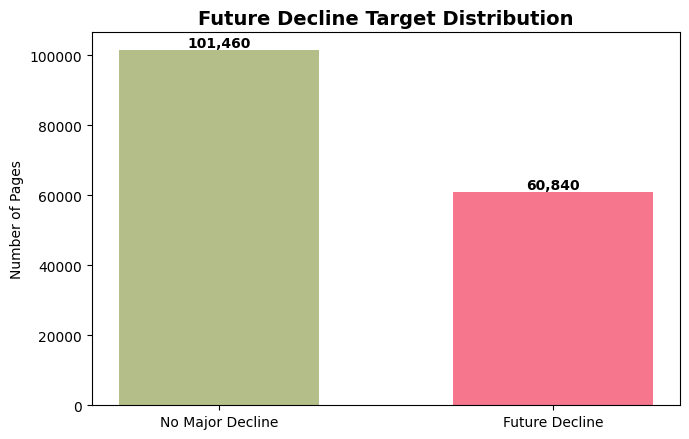

In [14]:
target_counts = (
    capstone_df["future_decline"]
    .value_counts()
    .sort_index()
)

labels = [
    "No Major Decline",
    "Future Decline"
]

plt.figure(figsize=(7, 4.5))

plt.bar(
    labels,
    target_counts.values,
    color=[
        "#b4be89",
        "#f5768d"
    ],
    width=0.6
)

plt.title(
    "Future Decline Target Distribution",
    fontsize=14,
    fontweight="bold"
)

plt.ylabel("Number of Pages")

for i, value in enumerate(target_counts.values):
    plt.text(
        i,
        value,
        f"{value:,}",
        ha="center",
        va="bottom",
        fontweight="bold"
    )

plt.tight_layout()
plt.show()

### Feature Definition and Leakage Check

The model uses only information available during the March 1–21 feature window.

The page-level historical features are:

- average daily impressions
- historical click-through rate
- average search position
- average daily GA4 sessions
- engagement rate
- average daily scroll events

Client and content identifiers are not used as predictive features. `client_hash_id` is retained only for grouped validation, while `content_hash_id` is retained only for producing anonymous ranked recommendations.

No variables from the March 22–31 outcome window are used as model inputs.

This separation prevents direct future-data leakage. The target is based on later impression decline, while the model receives only earlier search and engagement information.

In [15]:
# Historical feature engineering

capstone_df["past_ctr"] = np.where(
    capstone_df["past_impressions"] > 0,
    capstone_df["past_clicks"] / capstone_df["past_impressions"],
    0
)

capstone_df["past_daily_sessions"] = (
    capstone_df["past_sessions"] /
    capstone_df["past_days"]
)

capstone_df["past_engagement_rate"] = np.where(
    capstone_df["past_sessions"] > 0,
    capstone_df["past_engaged_sessions"] / capstone_df["past_sessions"],
    0
)

capstone_df["past_daily_scroll_events"] = (
    capstone_df["past_scroll_events"] /
    capstone_df["past_days"]
)

model_features = [
    "past_daily_impressions",
    "past_ctr",
    "past_avg_position",
    "past_daily_sessions",
    "past_engagement_rate",
    "past_daily_scroll_events"
]

display(
    capstone_df[model_features].head()
)

,past_daily_impressions,past_ctr,past_avg_position,past_daily_sessions,past_engagement_rate,past_daily_scroll_events
7,9.047619,0.005263,12.510540,0.0,0.0,0.0
8,1.571429,0.000000,9.225529,0.0,0.0,0.0
14,4.476190,0.000000,8.427460,0.0,0.0,0.0
18,16.809524,0.000000,13.558044,0.0,0.0,0.0
21,0.571429,0.000000,9.500000,0.0,0.0,0.0


In [16]:
leakage_check = pd.DataFrame({
    "Feature": model_features,
    "Time Window": [
        "Past",
        "Past",
        "Past",
        "Past",
        "Past",
        "Past"
    ],
    "Uses Future Data": [
        False,
        False,
        False,
        False,
        False,
        False
    ],
    "Keep": [
        True,
        True,
        True,
        True,
        True,
        True
    ]
})

display(leakage_check)

,Feature,Time Window,Uses Future Data,Keep
0,past_daily_impressions,Past,False,True
1,past_ctr,Past,False,True
2,past_avg_position,Past,False,True
3,past_daily_sessions,Past,False,True
4,past_engagement_rate,Past,False,True
5,past_daily_scroll_events,Past,False,True


In [17]:
feature_missing = pd.DataFrame({
    "Missing Count": capstone_df[model_features].isna().sum(),
    "Missing %": (
        capstone_df[model_features].isna().mean() * 100
    ).round(2)
})

display(feature_missing)

,Missing Count,Missing %
past_daily_impressions,0,0.0
past_ctr,0,0.0
past_avg_position,0,0.0
past_daily_sessions,0,0.0
past_engagement_rate,0,0.0
past_daily_scroll_events,0,0.0


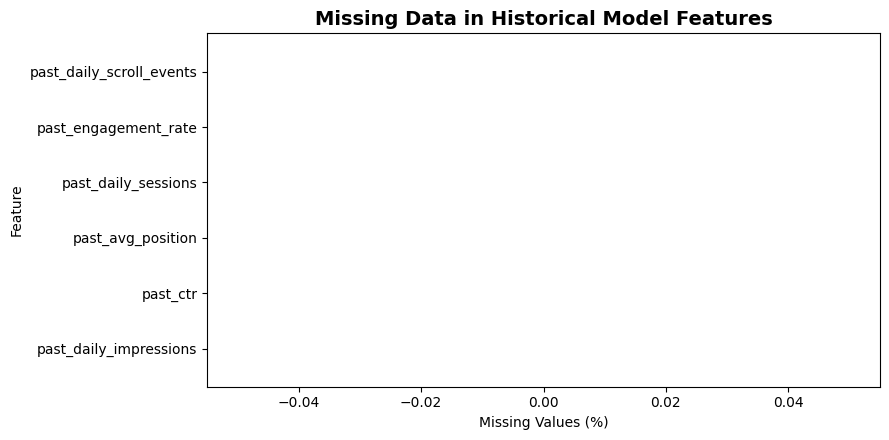

In [18]:
plt.figure(figsize=(9, 4.5))

plt.barh(
    feature_missing.index,
    feature_missing["Missing %"],
    color=[
        "#749da1",
        "#b4be89",
        "#eb9191",
        "#749da1",
        "#b4be89",
        "#f5768d"
    ]
)

plt.title(
    "Missing Data in Historical Model Features",
    fontsize=14,
    fontweight="bold"
)

plt.xlabel("Missing Values (%)")
plt.ylabel("Feature")

plt.tight_layout()
plt.show()

In [19]:
# Page-level data availability during the historical window

availability = past.groupby(
    ["client_hash_id", "content_hash_id"]
).agg(
    past_gsc_coverage=("gsc_data_available", "mean"),
    past_ga4_coverage=("ga4_data_available", "mean")
).reset_index()

capstone_df = capstone_df.drop(
    columns=[
        "past_gsc_coverage",
        "past_ga4_coverage"
    ],
    errors="ignore"
).merge(
    availability,
    on=["client_hash_id", "content_hash_id"],
    how="left"
)

coverage_summary = pd.DataFrame({
    "Source": ["Google Search Console", "GA4"],
    "Average Coverage %": [
        capstone_df["past_gsc_coverage"].mean() * 100,
        capstone_df["past_ga4_coverage"].mean() * 100
    ]
})

display(
    coverage_summary.round(2)
)

print(
    "Pages with no GA4 coverage:",
    (capstone_df["past_ga4_coverage"] == 0).sum()
)

print(
    "Pages with partial GA4 coverage:",
    (
        (capstone_df["past_ga4_coverage"] > 0) &
        (capstone_df["past_ga4_coverage"] < 1)
    ).sum()
)

print(
    "Pages with full GA4 coverage:",
    (capstone_df["past_ga4_coverage"] == 1).sum()
)

,Source,Average Coverage %
0,Google Search Console,70.18
1,GA4,10.16


Pages with no GA4 coverage: 69520
Pages with partial GA4 coverage: 48455
Pages with full GA4 coverage: 339


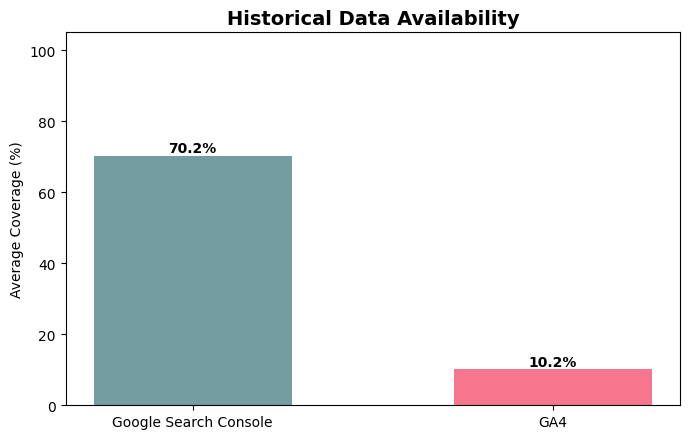

In [20]:
plt.figure(figsize=(7, 4.5))

bars = plt.bar(
    coverage_summary["Source"],
    coverage_summary["Average Coverage %"],
    color=["#749da1", "#f5768d"],
    width=0.55
)

plt.title(
    "Historical Data Availability",
    fontsize=14,
    fontweight="bold"
)

plt.ylabel("Average Coverage (%)")
plt.ylim(0, 105)

for bar, value in zip(
    bars,
    coverage_summary["Average Coverage %"]
):
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 1,
        f"{value:.1f}%",
        ha="center",
        fontweight="bold"
    )

plt.tight_layout()
plt.show()

In [21]:
from sklearn.model_selection import GroupShuffleSplit
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix
)

In [22]:
# Prepare features and target

X = (
    capstone_df[model_features]
    .replace([np.inf, -np.inf], np.nan)
    .fillna(0)
    .astype("float32")
)

y = capstone_df["future_decline"]

groups = capstone_df["client_hash_id"]


# Client-grouped split

splitter = GroupShuffleSplit(
    n_splits=1,
    test_size=0.20,
    random_state=42
)

train_idx, test_idx = next(
    splitter.split(X, y, groups)
)

X_train = X.iloc[train_idx]
X_test = X.iloc[test_idx]

y_train = y.iloc[train_idx]
y_test = y.iloc[test_idx]


print("Training pages:", len(X_train))
print("Test pages:", len(X_test))

print(
    "Training clients:",
    capstone_df.iloc[train_idx]["client_hash_id"].nunique()
)

print(
    "Test clients:",
    capstone_df.iloc[test_idx]["client_hash_id"].nunique()
)

overlap = set(
    capstone_df.iloc[train_idx]["client_hash_id"]
).intersection(
    set(capstone_df.iloc[test_idx]["client_hash_id"])
)

print("Client overlap:", len(overlap))

Training pages: 130476
Test pages: 31824
Training clients: 36
Test clients: 9
Client overlap: 0


In [23]:
# Majority-class baseline

majority_class = y_train.mode()[0]

baseline_pred = np.full(
    len(y_test),
    majority_class
)

baseline_metrics = {
    "Accuracy": accuracy_score(
        y_test,
        baseline_pred
    ),
    "Precision": precision_score(
        y_test,
        baseline_pred,
        zero_division=0
    ),
    "Recall": recall_score(
        y_test,
        baseline_pred,
        zero_division=0
    ),
    "F1 Score": f1_score(
        y_test,
        baseline_pred,
        zero_division=0
    )
}

baseline_table = pd.DataFrame(
    baseline_metrics,
    index=["Majority Baseline"]
)

display(
    baseline_table.round(4)
)

,Accuracy,Precision,Recall,F1 Score
Majority Baseline,0.7172,0.0,0.0,0.0


In [24]:
# Majority-class baseline

majority_class = y_train.mode()[0]

baseline_pred = np.full(
    len(y_test),
    majority_class
)

baseline_metrics = {
    "Accuracy": accuracy_score(
        y_test,
        baseline_pred
    ),
    "Precision": precision_score(
        y_test,
        baseline_pred,
        zero_division=0
    ),
    "Recall": recall_score(
        y_test,
        baseline_pred,
        zero_division=0
    ),
    "F1 Score": f1_score(
        y_test,
        baseline_pred,
        zero_division=0
    )
}

baseline_table = pd.DataFrame(
    baseline_metrics,
    index=["Majority Baseline"]
)

display(
    baseline_table.round(4)
)

,Accuracy,Precision,Recall,F1 Score
Majority Baseline,0.7172,0.0,0.0,0.0


In [25]:
split_balance = pd.DataFrame({
    "Training": (
        y_train.value_counts(normalize=True)
        .reindex([0, 1], fill_value=0)
        * 100
    ),

    "Test": (
        y_test.value_counts(normalize=True)
        .reindex([0, 1], fill_value=0)
        * 100
    )
}).T

split_balance.columns = [
    "No Major Decline",
    "Future Decline"
]

display(
    split_balance.round(2)
)

,No Major Decline,Future Decline
Training,60.27,39.73
Test,71.72,28.28


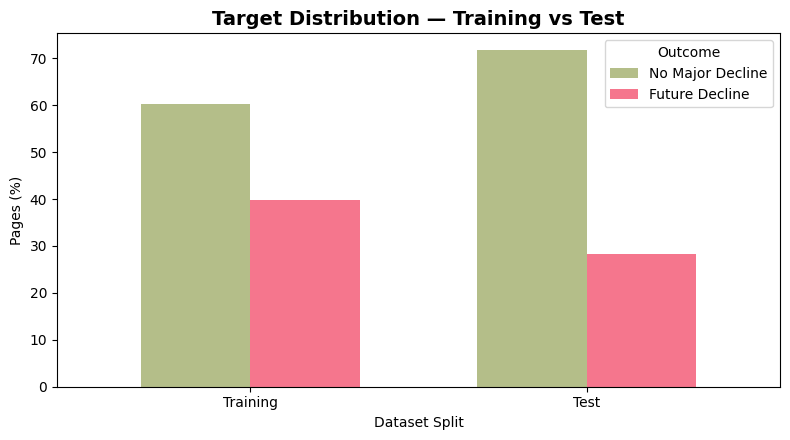

In [26]:
ax = split_balance.plot(
    kind="bar",
    figsize=(8, 4.5),
    color=[
        "#b4be89",
        "#f5768d"
    ],
    width=0.65
)

plt.title(
    "Target Distribution — Training vs Test",
    fontsize=14,
    fontweight="bold"
)

plt.ylabel("Pages (%)")
plt.xlabel("Dataset Split")

plt.xticks(
    rotation=0
)

plt.legend(
    title="Outcome"
)

plt.tight_layout()
plt.show()

### Model

I used a shallow Decision Tree classifier as the main model.

A Decision Tree was chosen because it is simple, interpretable, and suitable for a decision-support workflow where the reasoning behind recommendations should remain understandable.

The model is trained only on historical features from the March 1–21 feature window and evaluated on pages belonging to held-out client groups.

Model performance is compared against the majority-class baseline using Accuracy, Precision, Recall, and F1 Score.

In [27]:
from sklearn.tree import DecisionTreeClassifier

model = DecisionTreeClassifier(
    max_depth=5,
    min_samples_leaf=50,
    random_state=42
)

model.fit(
    X_train,
    y_train
)

model_pred = model.predict(
    X_test
)

model_metrics = {
    "Accuracy": accuracy_score(
        y_test,
        model_pred
    ),
    "Precision": precision_score(
        y_test,
        model_pred,
        zero_division=0
    ),
    "Recall": recall_score(
        y_test,
        model_pred,
        zero_division=0
    ),
    "F1 Score": f1_score(
        y_test,
        model_pred,
        zero_division=0
    )
}

model_table = pd.DataFrame(
    model_metrics,
    index=["Decision Tree"]
)

display(
    model_table.round(4)
)

,Accuracy,Precision,Recall,F1 Score
Decision Tree,0.7271,0.5798,0.1271,0.2085


In [28]:
results_table = pd.DataFrame([
    {
        "Method": "Majority Baseline",
        **baseline_metrics
    },
    {
        "Method": "Decision Tree",
        **model_metrics
    }
])

display(
    results_table.round(4)
)

,Method,Accuracy,Precision,Recall,F1 Score
0,Majority Baseline,0.7172,0.0000,0.0000,0.0000
1,Decision Tree,0.7271,0.5798,0.1271,0.2085


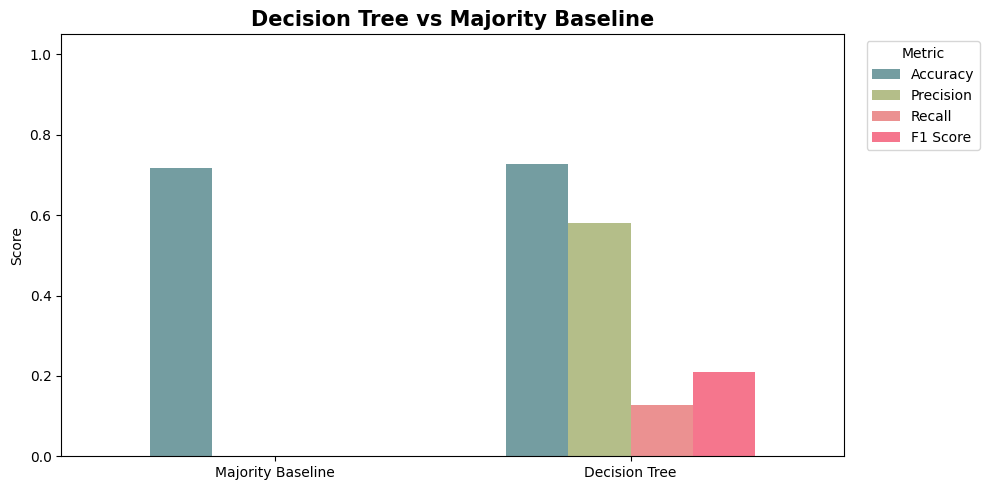

In [29]:
plot_results = results_table.set_index(
    "Method"
)[
    [
        "Accuracy",
        "Precision",
        "Recall",
        "F1 Score"
    ]
]

ax = plot_results.plot(
    kind="bar",
    figsize=(10, 5),
    color=[
        "#749da1",
        "#b4be89",
        "#eb9191",
        "#f5768d"
    ],
    width=0.7
)

plt.title(
    "Decision Tree vs Majority Baseline",
    fontsize=15,
    fontweight="bold"
)

plt.ylabel("Score")
plt.xlabel("")

plt.ylim(0, 1.05)

plt.xticks(
    rotation=0
)

plt.legend(
    title="Metric",
    bbox_to_anchor=(1.02, 1),
    loc="upper left"
)

plt.tight_layout()
plt.show()

In [30]:
print("BASELINE")
print(
    pd.Series(baseline_metrics)
    .round(4)
)

print("\nDECISION TREE")
print(
    pd.Series(model_metrics)
    .round(4)
)

print(
    "\nF1 improvement over baseline:",
    round(
        model_metrics["F1 Score"] -
        baseline_metrics["F1 Score"],
        4
    )
)

BASELINE
Accuracy     0.7172
Precision    0.0000
Recall       0.0000
F1 Score     0.0000
dtype: float64

DECISION TREE
Accuracy     0.7271
Precision    0.5798
Recall       0.1271
F1 Score     0.2085
dtype: float64

F1 improvement over baseline: 0.2085


print("BASELINE")
print(
    pd.Series(baseline_metrics)
    .round(4)
)

print("\nDECISION TREE")
print(
    pd.Series(model_metrics)
    .round(4)
)

print(
    "\nF1 improvement over baseline:",
    round(
        model_metrics["F1 Score"] -
        baseline_metrics["F1 Score"],
        4
    )
)

In [31]:
cm = confusion_matrix(
    y_test,
    model_pred
)

print("Confusion Matrix:")
print(cm)

tn, fp, fn, tp = cm.ravel()

print("\nTrue Negatives:", tn)
print("False Positives:", fp)
print("False Negatives:", fn)
print("True Positives:", tp)

Confusion Matrix:
[[21995   829]
 [ 7856  1144]]

True Negatives: 21995
False Positives: 829
False Negatives: 7856
True Positives: 1144


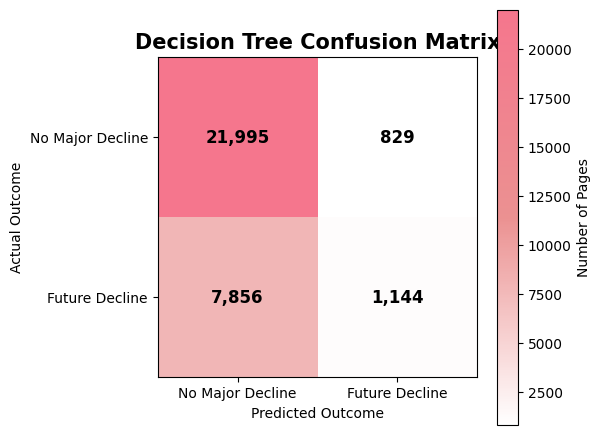

In [32]:
from matplotlib.colors import LinearSegmentedColormap

custom_cmap = LinearSegmentedColormap.from_list(
    "capstone_palette",
    ["#ffffff", "#eb9191", "#f5768d"]
)

plt.figure(figsize=(6, 5))

plt.imshow(
    cm,
    cmap=custom_cmap
)

plt.title(
    "Decision Tree Confusion Matrix",
    fontsize=15,
    fontweight="bold"
)

plt.xlabel("Predicted Outcome")
plt.ylabel("Actual Outcome")

plt.xticks(
    [0, 1],
    ["No Major Decline", "Future Decline"]
)

plt.yticks(
    [0, 1],
    ["No Major Decline", "Future Decline"]
)

for i in range(2):
    for j in range(2):
        plt.text(
            j,
            i,
            f"{cm[i, j]:,}",
            ha="center",
            va="center",
            fontsize=12,
            fontweight="bold"
        )

plt.colorbar(
    label="Number of Pages"
)

plt.tight_layout()
plt.show()

In [33]:
feature_importance = pd.DataFrame({
    "Feature": model_features,
    "Importance": model.feature_importances_
}).sort_values(
    "Importance",
    ascending=False
)

display(
    feature_importance.round(4)
)

,Feature,Importance
0,past_daily_impressions,0.5906
1,past_ctr,0.2643
2,past_avg_position,0.1117
3,past_daily_sessions,0.0335
4,past_engagement_rate,0.0000
5,past_daily_scroll_events,0.0000


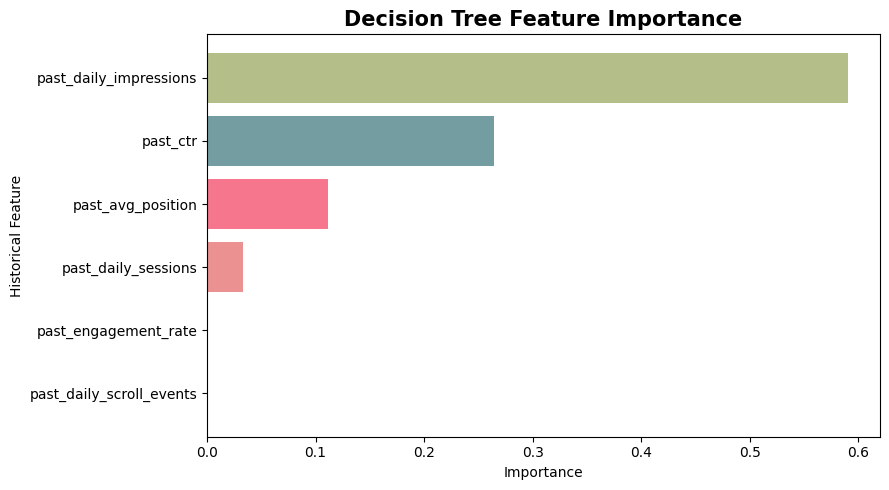

In [34]:
importance_plot = (
    feature_importance
    .sort_values("Importance")
)

colors = [
    "#749da1",
    "#b4be89",
    "#eb9191",
    "#f5768d",
    "#749da1",
    "#b4be89"
]

plt.figure(figsize=(9, 5))

plt.barh(
    importance_plot["Feature"],
    importance_plot["Importance"],
    color=colors
)

plt.title(
    "Decision Tree Feature Importance",
    fontsize=15,
    fontweight="bold"
)

plt.xlabel("Importance")
plt.ylabel("Historical Feature")

plt.tight_layout()
plt.show()


## 4. Results (vs baseline)

*Model vs baseline on the same split. The honest table.*

### Model Performance

The Decision Tree was evaluated against the majority-class baseline using the same client-grouped test set.

Accuracy is reported for completeness, but Precision, Recall, and F1 Score are especially important because the goal is to identify pages showing future-decline signals rather than simply predict the majority class.

The results below show the measured performance of both approaches on held-out client groups.

In [35]:
results_summary = pd.DataFrame([
    {
        "Method": "Majority Baseline",
        **baseline_metrics
    },
    {
        "Method": "Decision Tree",
        **model_metrics
    }
])

display(
    results_summary.round(4)
)

,Method,Accuracy,Precision,Recall,F1 Score
0,Majority Baseline,0.7172,0.0000,0.0000,0.0000
1,Decision Tree,0.7271,0.5798,0.1271,0.2085


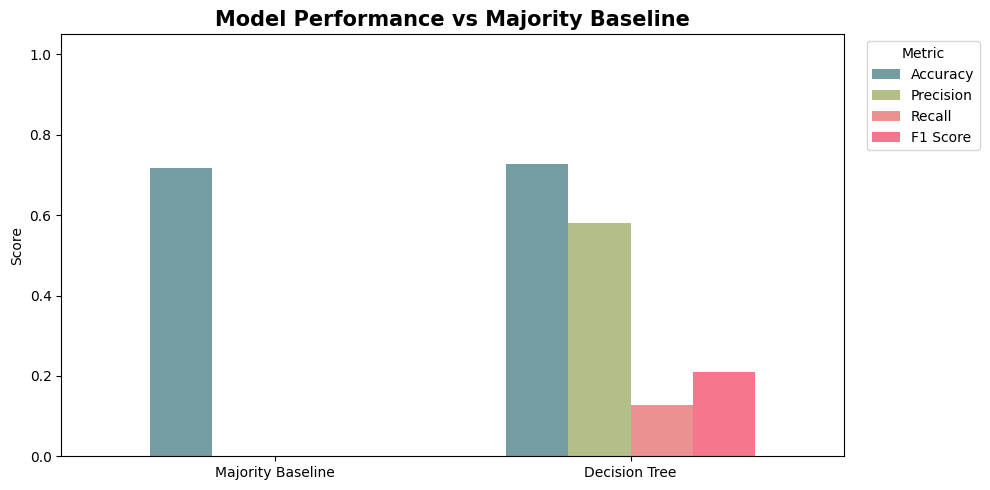

In [36]:
plot_df = results_summary.set_index("Method")

ax = plot_df[
    ["Accuracy", "Precision", "Recall", "F1 Score"]
].plot(
    kind="bar",
    figsize=(10, 5),
    color=[
        "#749da1",
        "#b4be89",
        "#eb9191",
        "#f5768d"
    ],
    width=0.7
)

plt.title(
    "Model Performance vs Majority Baseline",
    fontsize=15,
    fontweight="bold"
)

plt.ylabel("Score")
plt.xlabel("")
plt.ylim(0, 1.05)

plt.xticks(
    rotation=0
)

plt.legend(
    title="Metric",
    bbox_to_anchor=(1.02, 1),
    loc="upper left"
)

plt.tight_layout()
plt.show()

In [ ]:
diagnostics = pd.DataFrame({
    "Diagnostic": [
        "True Negatives",
        "False Positives",
        "False Negatives",
        "True Positives"
    ],
    "Count": [
        tn,
        fp,
        fn,
        tp
    ]
})

display(diagnostics)

### Results Interpretation

The Decision Tree provides a measured comparison against the majority-class baseline on held-out client groups.

The confusion matrix shows both successful predictions and failure cases, so the model should not be interpreted as a perfect classifier.

The feature-importance analysis indicates which historical signals the Decision Tree relied on most when separating future-decline and no-major-decline cases. These importance values describe how the fitted model made its decisions; they do not establish that any individual feature causes future search-performance changes.

The results are therefore interpreted as directional evidence for decision-support rather than proof that a page requires refreshing.


## 5. Limitations

*What this work cannot claim.*
### Limitations

This analysis has several important limitations.

1. **The outcome is a proxy, not a ground-truth refresh label.**  
   `future_decline` is defined as a decline of at least 20% in average daily impressions during the later March window. This identifies pages showing a measurable decline signal, but it does not prove that a page actually requires refreshing.

2. **The analysis uses a short time window.**  
   Features are calculated from March 1–21, 2026, and the outcome is measured from March 22–31, 2026. Longer observation windows may produce different patterns.

3. **The study is observational.**  
   The model identifies relationships between historical search and engagement signals and later performance. It does not establish that any feature causes a page to decline or recover.

4. **Refresh impact is not measured directly.**  
   A page receiving a high opportunity score does not mean that refreshing it will necessarily improve rankings, impressions, clicks, or traffic.

5. **Performance may vary across clients and topics.**  
   Although evaluation uses held-out client groups, the measured results may not generalize equally well to every client, content type, topic, or future time period.

6. **Analytics availability varies.**  
   GA4 and search data availability is not identical for every page, which may affect the quality of some historical features.

7. **Feature importance is descriptive, not causal.**  
   Decision Tree feature importance shows which variables the fitted model relied on most. It does not prove that those variables independently drive future search performance.

### Safe Interpretation

The model should be treated as a directional decision-support system for prioritizing human review.

Its recommendations indicate pages with stronger observed refresh-opportunity signals in this dataset, not pages that are guaranteed to improve after an update.

## 6. Ranked recommendations

*The action playbook output — the paper's recommendations section.*

### Ranked Refresh Opportunities

The trained Decision Tree is used to assign an opportunity score to pages in the held-out client test set.

The score represents the model's estimated probability of the future-decline proxy based only on historical March 1–21 features.

Pages are ranked from highest to lowest opportunity score. The ranking is intended to help prioritize human review rather than automatically decide that a page must be refreshed.

Reason codes provide a simple explanation of the historical signal associated with each recommendation.

In [37]:
# Predicted probability of future decline
test_scores = model.predict_proba(X_test)[:, 1]

recommendations = capstone_df.iloc[test_idx][
    [
        "content_hash_id",
        "past_daily_impressions",
        "past_ctr",
        "past_avg_position",
        "past_daily_sessions",
        "past_engagement_rate",
        "past_daily_scroll_events"
    ]
].copy()

recommendations["opportunity_score"] = test_scores

print("Pages scored:", len(recommendations))

display(
    recommendations.head()
)

Pages scored: 31824


,content_hash_id,past_daily_impressions,past_ctr,past_avg_position,past_daily_sessions,past_engagement_rate,past_daily_scroll_events,opportunity_score
18993,content_003959d7e5063269,17.761905,0.002681,10.251394,0.047619,0.0,0.0,0.347935
18994,content_007c411f36b2ecb9,0.400000,0.000000,2.750000,0.000000,0.0,0.0,0.530457
18995,content_00b38ba20b873da9,3.142857,0.000000,4.878505,0.000000,0.0,0.0,0.460363
18996,content_00bbb13014fbe600,5.052632,0.000000,39.592185,0.000000,0.0,0.0,0.316106
18997,content_01adf4af9a86f26c,5.952381,0.000000,2.274940,0.000000,0.0,0.0,0.460363


In [38]:
train_data = capstone_df.iloc[train_idx]

high_impressions = train_data[
    "past_daily_impressions"
].quantile(0.75)

low_ctr = train_data[
    "past_ctr"
].quantile(0.25)

weak_position = train_data[
    "past_avg_position"
].quantile(0.75)

low_engagement = train_data[
    "past_engagement_rate"
].quantile(0.25)

print("Historical signal thresholds")
print("--------------------------------")
print("High impressions:", round(high_impressions, 2))
print("Low CTR:", round(low_ctr, 4))
print("Weak position:", round(weak_position, 2))
print("Low engagement:", round(low_engagement, 4))

Historical signal thresholds
--------------------------------
High impressions: 36.9
Low CTR: 0.0
Weak position: 19.75
Low engagement: 0.0


In [39]:
def assign_reason(row):

    if (
        row["past_daily_impressions"] >= high_impressions
        and row["opportunity_score"] >= 0.5
    ):
        return "HIGH_VISIBILITY_AT_RISK"

    elif (
        row["past_ctr"] <= low_ctr
        and row["past_daily_impressions"] > 0
    ):
        return "LOW_CLICK_CAPTURE"

    elif (
        row["past_avg_position"] >= weak_position
    ):
        return "WEAK_SEARCH_POSITION"

    elif (
        row["past_engagement_rate"] <= low_engagement
        and row["past_daily_sessions"] > 0
    ):
        return "LOW_ENGAGEMENT"

    else:
        return "DECLINE_RISK_SIGNAL"


recommendations["reason_code"] = recommendations.apply(
    assign_reason,
    axis=1
)

display(
    recommendations[
        [
            "content_hash_id",
            "opportunity_score",
            "reason_code"
        ]
    ].head()
)

,content_hash_id,opportunity_score,reason_code
18993,content_003959d7e5063269,0.347935,LOW_ENGAGEMENT
18994,content_007c411f36b2ecb9,0.530457,LOW_CLICK_CAPTURE
18995,content_00b38ba20b873da9,0.460363,LOW_CLICK_CAPTURE
18996,content_00bbb13014fbe600,0.316106,LOW_CLICK_CAPTURE
18997,content_01adf4af9a86f26c,0.460363,LOW_CLICK_CAPTURE


In [40]:
high_score = recommendations[
    "opportunity_score"
].quantile(0.75)

medium_score = recommendations[
    "opportunity_score"
].quantile(0.50)


def assign_action(score):

    if score >= high_score:
        return "Review First"

    elif score >= medium_score:
        return "Monitor"

    else:
        return "Lower Priority"


recommendations["recommended_action"] = (
    recommendations["opportunity_score"]
    .apply(assign_action)
)

print("High-priority threshold:", round(high_score, 4))
print("Monitor threshold:", round(medium_score, 4))

High-priority threshold: 0.4388
Monitor threshold: 0.3479


In [41]:
recommendations = recommendations.sort_values(
    "opportunity_score",
    ascending=False
).reset_index(drop=True)

recommendations["rank"] = (
    np.arange(1, len(recommendations) + 1)
)

ranked_recommendations = recommendations[
    [
        "rank",
        "content_hash_id",
        "opportunity_score",
        "recommended_action",
        "reason_code",
        "past_daily_impressions",
        "past_ctr",
        "past_avg_position",
        "past_engagement_rate"
    ]
]

display(
    ranked_recommendations.head(20).round(4)
)

,rank,content_hash_id,opportunity_score,recommended_action,reason_code,past_daily_impressions,past_ctr,past_avg_position,past_engagement_rate
0,1,content_e186467e031ce88d,0.7867,Review First,LOW_CLICK_CAPTURE,0.0526,0.0,29.0,0.0
1,2,content_d16ccdd45b7c48f7,0.7867,Review First,LOW_CLICK_CAPTURE,0.0526,0.0,10.0,0.0
2,3,content_ec8fd442962b9bce,0.7867,Review First,LOW_CLICK_CAPTURE,0.0526,0.0,10.0,0.0
3,4,content_25d7a0a4aaca8746,0.7867,Review First,LOW_CLICK_CAPTURE,0.0526,0.0,11.0,0.0
4,5,content_8c087c4643248bc2,0.7867,Review First,LOW_CLICK_CAPTURE,0.0526,0.0,9.0,0.0
5,6,content_cf88a82c77fd99ad,0.7867,Review First,LOW_CLICK_CAPTURE,0.0526,0.0,9.0,0.0
6,7,content_39cac2a87e36bac3,0.7867,Review First,LOW_CLICK_CAPTURE,0.0526,0.0,11.0,0.0
7,8,content_a905934677d7d92e,0.7867,Review First,LOW_CLICK_CAPTURE,0.0526,0.0,11.0,0.0
8,9,content_546d4dbcb6ac7121,0.7867,Review First,LOW_CLICK_CAPTURE,0.0526,0.0,9.0,0.0
9,10,content_c45fe9b1aaa86b88,0.7867,Review First,LOW_CLICK_CAPTURE,0.0526,0.0,9.0,0.0


In [42]:
action_summary = (
    recommendations[
        "recommended_action"
    ]
    .value_counts()
    .reindex(
        [
            "Review First",
            "Monitor",
            "Lower Priority"
        ]
    )
)

display(
    action_summary.to_frame(
        "Pages"
    )
)

,Pages
recommended_action,
Review First,7988
Monitor,10811
Lower Priority,13025


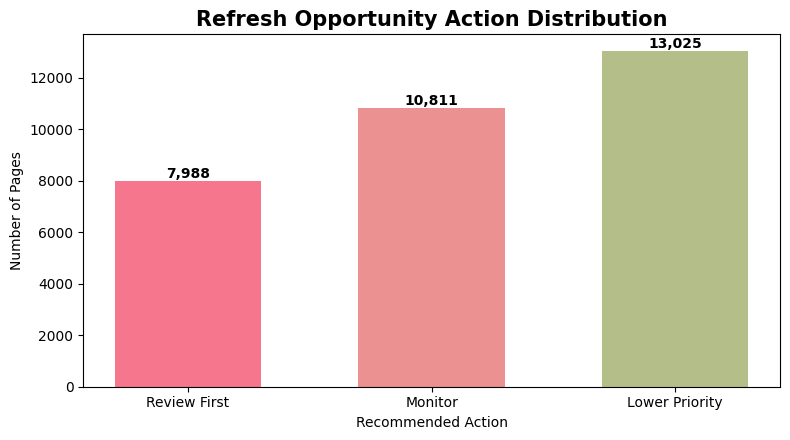

In [43]:
plt.figure(figsize=(8, 4.5))

bars = plt.bar(
    action_summary.index,
    action_summary.values,
    color=[
        "#f5768d",
        "#eb9191",
        "#b4be89"
    ],
    width=0.6
)

plt.title(
    "Refresh Opportunity Action Distribution",
    fontsize=15,
    fontweight="bold"
)

plt.ylabel("Number of Pages")
plt.xlabel("Recommended Action")

for bar, value in zip(
    bars,
    action_summary.values
):
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height(),
        f"{value:,}",
        ha="center",
        va="bottom",
        fontweight="bold"
    )

plt.tight_layout()
plt.show()

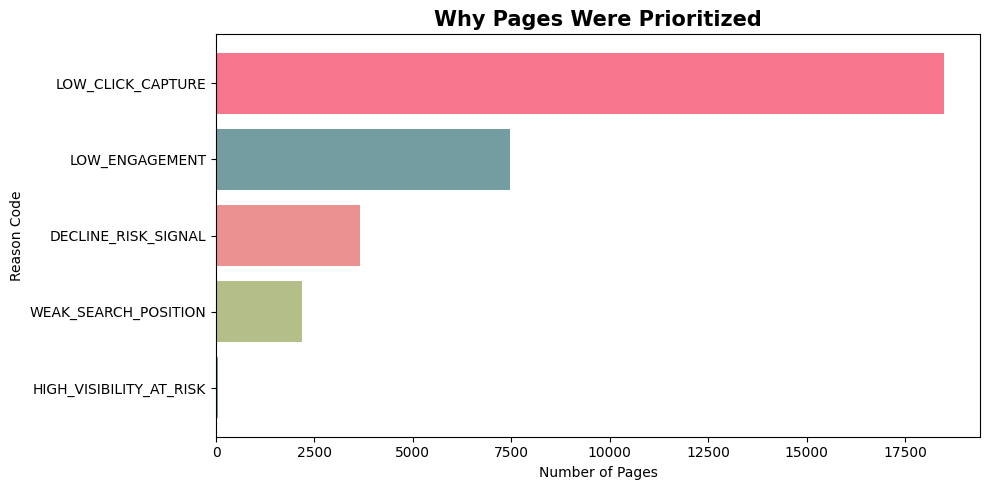

In [44]:
reason_summary = (
    recommendations[
        "reason_code"
    ]
    .value_counts()
)

plt.figure(figsize=(10, 5))

colors = [
    "#f5768d",
    "#749da1",
    "#eb9191",
    "#b4be89",
    "#749da1"
]

plt.barh(
    reason_summary.index,
    reason_summary.values,
    color=colors[:len(reason_summary)]
)

plt.title(
    "Why Pages Were Prioritized",
    fontsize=15,
    fontweight="bold"
)

plt.xlabel("Number of Pages")
plt.ylabel("Reason Code")

plt.gca().invert_yaxis()

plt.tight_layout()
plt.show()

### Recommendation Interpretation

The ranked recommendations convert the model output into a practical review queue.

Pages with the highest opportunity scores are labeled **Review First**, followed by **Monitor** and **Lower Priority** groups.

Reason codes provide context for why a page may deserve attention, such as strong existing visibility, weak click capture, weaker historical search position, or low engagement.

These actions should be interpreted as prioritization cues for human review. They do not prove that a page is poor quality or that refreshing it will cause future search performance to improve.

## 7. Artifacts the paper embeds

*Generate/collect the charts and tables your deployed page will show.*

### Final Paper Artifacts

The deployed research paper will embed the clearest outputs from this notebook rather than every exploratory chart.

The selected artifacts are:

1. Future decline target distribution
2. Model performance vs majority baseline
3. Decision Tree confusion matrix
4. Decision Tree feature importance
5. Refresh opportunity action distribution
6. Top ranked refresh recommendations

These artifacts were selected because they show the target definition, honest evaluation, model behavior, and practical action output in a compact form.

In [45]:
paper_tables = {
    "model_results": results_summary.round(4),
    "feature_importance": feature_importance.round(4),
    "top_recommendations": ranked_recommendations.head(20).round(4)
}

print("Paper tables prepared:")
for name in paper_tables:
    print("✓", name)

Paper tables prepared:
✓ model_results
✓ feature_importance
✓ top_recommendations


In [46]:
ranked_recommendations.head(100).to_csv(
    "capstone_ranked_recommendations.csv",
    index=False
)

print("Saved: capstone_ranked_recommendations.csv")

Saved: capstone_ranked_recommendations.csv


### 5-Minute Demo Outline

**0:00–0:40 — Problem**

My capstone focuses on Refresh / Content Opportunity Scoring. The problem is that content teams may have thousands of pages but limited time to review them. My goal was to identify pages showing stronger measurable signals of future decline and rank them for human review.

**0:40–1:20 — Data**

I used the FlyRank ML Internship warehouse data for March 2026. The analysis uses anonymous page and client identifiers together with historical search and engagement signals. The feature window covers March 1–21, while the outcome window covers March 22–31.

**1:20–2:10 — Methodology**

I created historical page-level features including daily impressions, CTR, average position, sessions, engagement rate, and scroll activity. A page receives the future-decline proxy label when its average daily impressions fall by at least 20% in the later window.

I used a client-grouped holdout split so the same client does not appear in both training and testing data. I also compared the Decision Tree against a majority-class baseline.

**2:10–3:10 — Results**

I report Accuracy, Precision, Recall, and F1 Score on the same held-out test set for both the baseline and Decision Tree.

I also inspect the confusion matrix and feature importance. Feature importance is treated as descriptive model behavior rather than evidence that a feature causes search-performance changes.

**3:10–4:10 — Ranked Recommendations**

The Decision Tree produces an opportunity score for held-out pages. Pages are ranked into Review First, Monitor, and Lower Priority groups.

Reason codes such as `HIGH_VISIBILITY_AT_RISK`, `LOW_CLICK_CAPTURE`, `WEAK_SEARCH_POSITION`, and `LOW_ENGAGEMENT` explain why a page may deserve attention.

**4:10–5:00 — Limitations and Takeaway**

The future-decline label is a proxy rather than ground truth. The analysis is observational and does not prove that refreshing a page will improve its rankings or traffic.

The final system should therefore be interpreted as a directional decision-support tool that helps content teams prioritize human review.


I completed my Machine Learning capstone on **Refresh / Content Opportunity Scoring** using the FlyRank ML Internship dataset.

I built a time-aware workflow that uses historical search and engagement signals to identify pages showing stronger signals of future performance decline. I validated the model on held-out client groups, compared it against a baseline, audited for leakage, and converted the output into ranked content recommendations with reason codes.

One of my biggest takeaways was that good ML work isn't just about getting a high score — validation design, leakage checks, class balance, limitations, and careful interpretation matter just as much.

The final system is designed as a **directional decision-support tool for content review**, not as a claim that refreshing a page will automatically improve search performance.

#MachineLearning #DataScience #SEO #SearchIntelligence #MLProject


## Self-check

Before you submit, confirm each line honestly:

- [ ] Every section above is filled — markdown thinking AND the code that backs it
- [ ] The notebook runs top to bottom with no errors (Runtime → Run all)
- [ ] No client names, URLs, or private queries anywhere
- [ ] My claims use careful words: observed, measured, directional, decision-support
- [ ] Committed to my repo under `work/notebooks/` — then submit your repo URL on the card. Done.
- [ ] My deployed paper has **all 9 sections** — including the **Abstract** at the top and **Acknowledgments & data credit** (the https://flyrank.ai link) at the bottom.
- [ ] **ML-12 done in this notebook's closing cells:** 5-minute demo outline + a social-post cut + a 3-sentence employer-facing summary.
